In [ ]:
%pip install pandas matplotlib seaborn scipy scikit-learn numpy

### Nạp thư viện

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, silhouette_samples
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualization
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

✅ All libraries imported successfully!
Pandas version: 2.3.3
NumPy version: 2.3.3


### Tải và khám phá dữ liệu

In [3]:
# Load the dataset
# Download from: https://www.kaggle.com/code/youssefaboelwafa/clustering-penguins-species-k-means-clustering
url = 'https://raw.githubusercontent.com/allisonhorst/palmerpenguins/master/inst/extdata/penguins.csv'
df = pd.read_csv(url)

# Display basic information
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

print("\nDataset info:")
print(df.info())

print("\nStatistical summary:")
print(df.describe())

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (344, 8)

First few rows:
  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  year  
0       3750.0    male  2007  
1       3800.0  female  2007  
2       3250.0  female  2007  
3          NaN     NaN  2007  
4       3450.0  female  2007  

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_

### Tiền xử lý dữ liệu

In [5]:
# Data preprocessing
# Remove rows with missing values
df_clean = df.dropna()

print(f"Original dataset size: {len(df)}")
print(f"Cleaned dataset size: {len(df_clean)}")

# Select numerical features for clustering
features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
X = df_clean[features]

print("\nFeatures selected for clustering:")
print(X.head())

# Save the species labels for later validation
true_labels = df_clean['species']

# Standardize the features (important for hierarchical clustering)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for easier handling
X_scaled_df = pd.DataFrame(X_scaled, columns=features, index=X.index)

print("Scaled data statistics:")
print(X_scaled_df.describe())

Original dataset size: 344
Cleaned dataset size: 333

Features selected for clustering:
   bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
0            39.1           18.7              181.0       3750.0
1            39.5           17.4              186.0       3800.0
2            40.3           18.0              195.0       3250.0
4            36.7           19.3              193.0       3450.0
5            39.3           20.6              190.0       3650.0
Scaled data statistics:
       bill_length_mm  bill_depth_mm  flipper_length_mm   body_mass_g
count    3.330000e+02   3.330000e+02       3.330000e+02  3.330000e+02
mean    -1.024206e-15  -1.280257e-15       2.560514e-16 -1.280257e-16
std      1.001505e+00   1.001505e+00       1.001505e+00  1.001505e+00
min     -2.177987e+00  -2.067291e+00      -2.069852e+00 -1.874435e+00
25%     -8.227879e-01  -7.958519e-01      -7.836512e-01 -8.172292e-01
50%      9.288742e-02   6.872642e-02      -2.834620e-01 -1.953432e-01
75%     

### Tạo ma trận khoảng cách và dendrogram

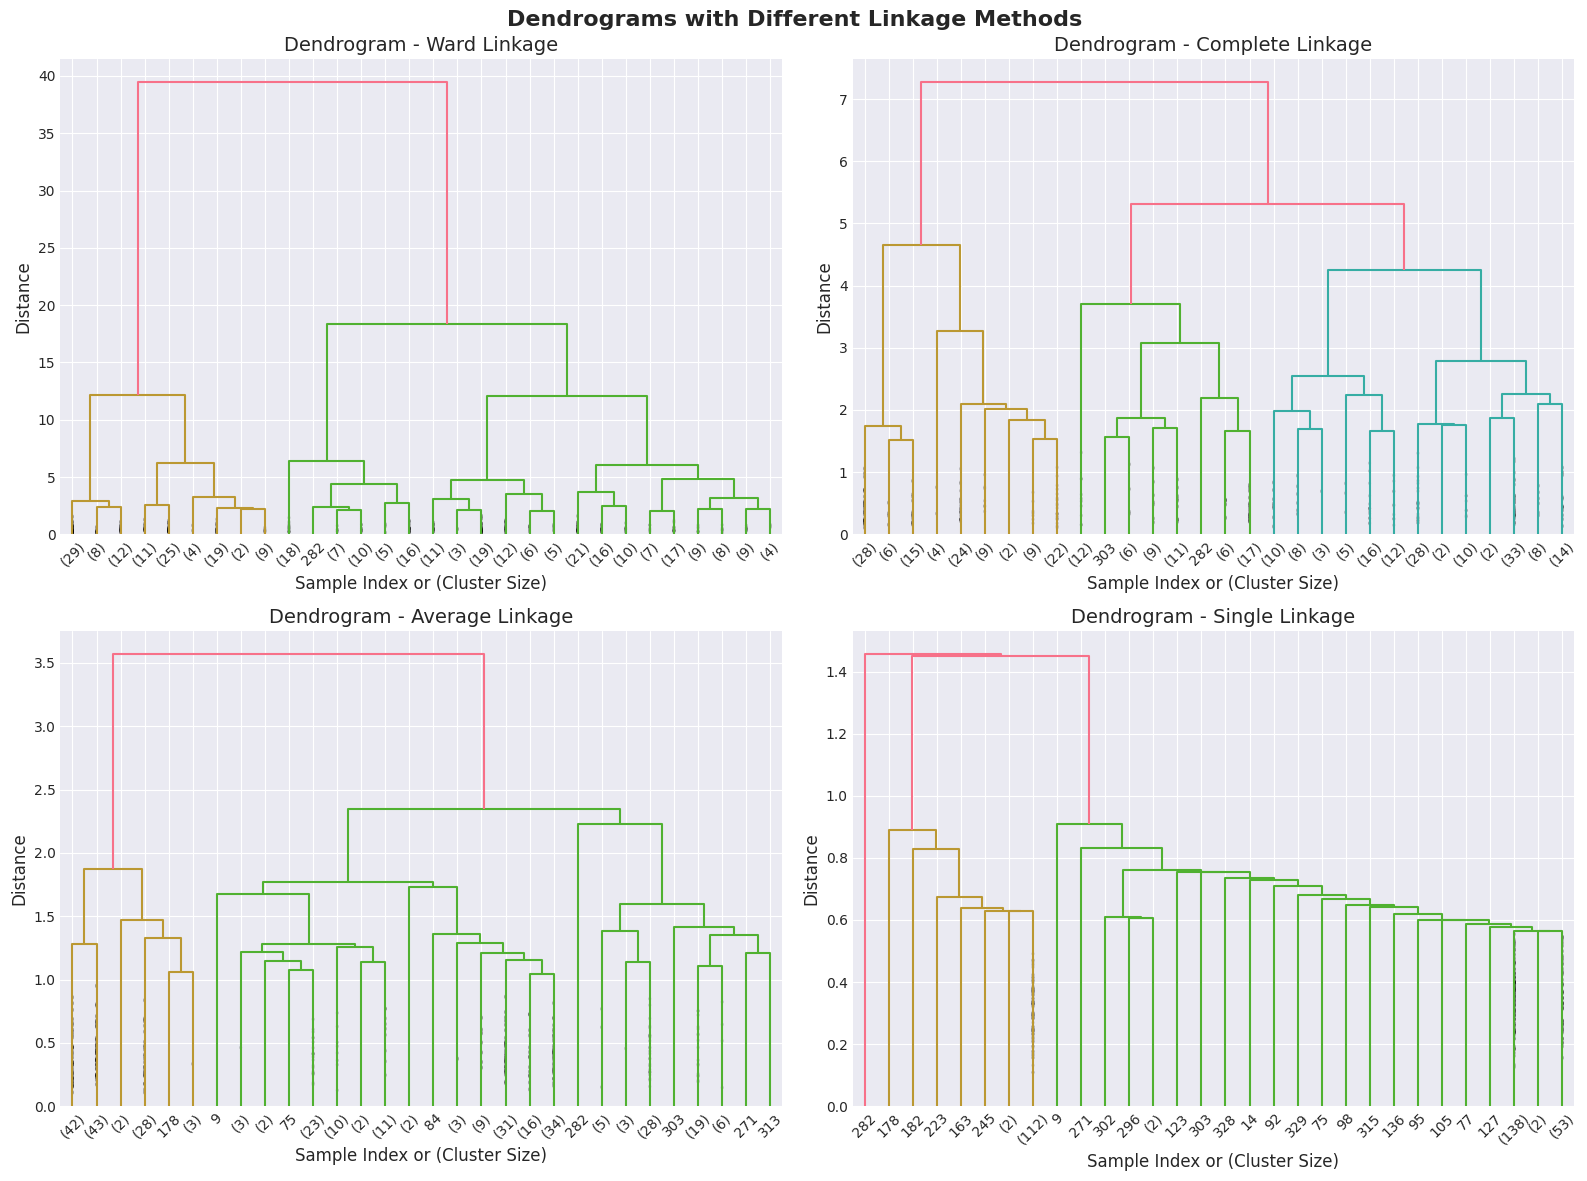

In [6]:
# Calculate linkage matrix using different methods
# Methods: 'single', 'complete', 'average', 'ward'
linkage_methods = ['ward', 'complete', 'average', 'single']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Dendrograms with Different Linkage Methods', fontsize=16, fontweight='bold')

for idx, method in enumerate(linkage_methods):
    row = idx // 2
    col = idx % 2
    
    # Calculate linkage
    Z = linkage(X_scaled, method=method)
    
    # Plot dendrogram
    dendrogram(Z, ax=axes[row, col], truncate_mode='lastp', p=30, 
               leaf_font_size=10, show_contracted=True)
    axes[row, col].set_title(f'Dendrogram - {method.capitalize()} Linkage', fontsize=14)
    axes[row, col].set_xlabel('Sample Index or (Cluster Size)', fontsize=12)
    axes[row, col].set_ylabel('Distance', fontsize=12)

plt.tight_layout()
plt.show()

### Trực quan hóa kết quả phân cụm


Number of clusters: 2
Cluster distribution:
0    214
1    119
Name: count, dtype: int64

Number of clusters: 3
Cluster distribution:
0    119
1    157
2     57
Name: count, dtype: int64

Number of clusters: 4
Cluster distribution:
0    157
1     70
2     57
3     49
Name: count, dtype: int64

Number of clusters: 5
Cluster distribution:
0     57
1     70
2    101
3     49
4     56
Name: count, dtype: int64

Number of clusters: 6
Cluster distribution:
0     70
1     56
2    101
3     49
4     39
5     18
Name: count, dtype: int64


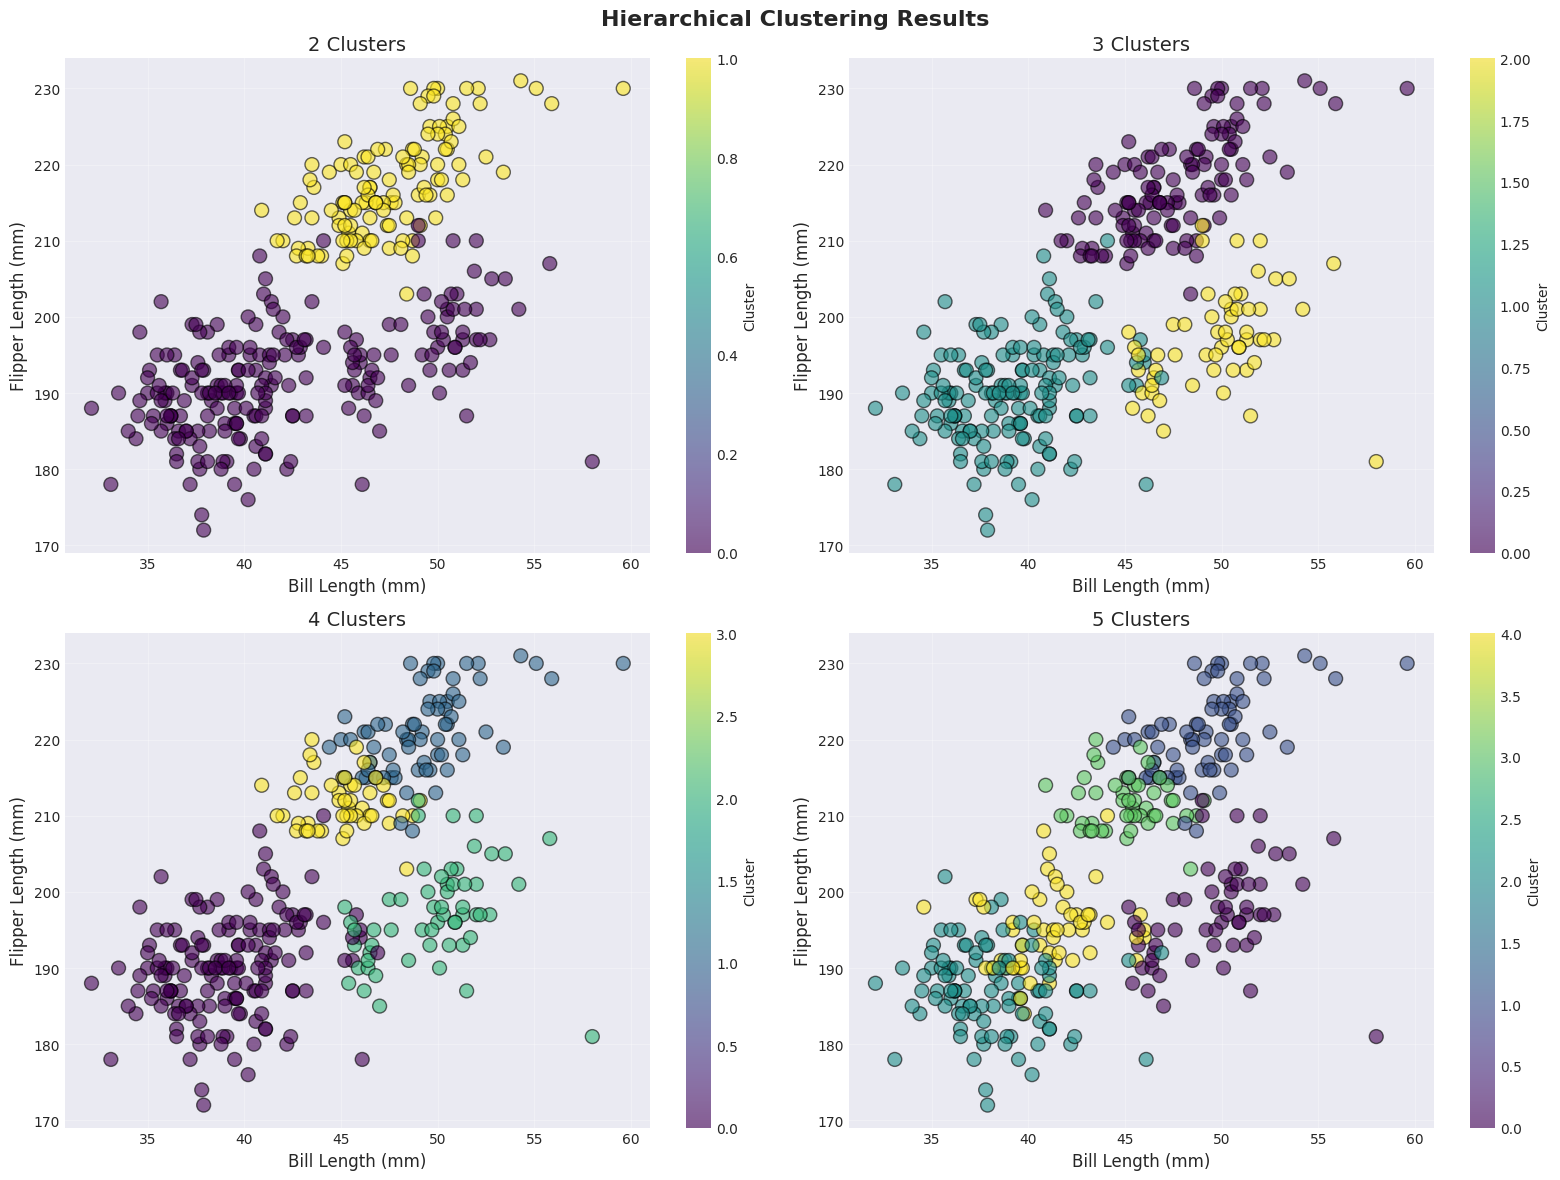

In [8]:
# Try different numbers of clusters
n_clusters_range = range(2, 7)

results = {}

for n_clusters in n_clusters_range:
    # Perform Agglomerative Clustering
    hierarchical = AgglomerativeClustering(n_clusters=n_clusters, 
                                          linkage='ward')
    clusters = hierarchical.fit_predict(X_scaled)
    
    results[n_clusters] = clusters
    
    # Add cluster labels to dataframe
    df_clean.loc[:, f'cluster_{n_clusters}'] = clusters
    
    print(f"\n{'='*50}")
    print(f"Number of clusters: {n_clusters}")
    print(f"{'='*50}")
    print(f"Cluster distribution:")
    print(pd.Series(clusters).value_counts().sort_index())

    # Visualize clustering results for different numbers of clusters
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Hierarchical Clustering Results', fontsize=16, fontweight='bold')

cluster_configs = [2, 3, 4, 5]

for idx, n_clusters in enumerate(cluster_configs):
    row = idx // 2
    col = idx % 2
    
    # Use PCA or select two features for 2D visualization
    # Here we use bill_length_mm vs flipper_length_mm
    scatter = axes[row, col].scatter(X['bill_length_mm'], 
                                     X['flipper_length_mm'],
                                     c=results[n_clusters], 
                                     cmap='viridis',
                                     s=100, 
                                     alpha=0.6,
                                     edgecolors='black')
    
    axes[row, col].set_xlabel('Bill Length (mm)', fontsize=12)
    axes[row, col].set_ylabel('Flipper Length (mm)', fontsize=12)
    axes[row, col].set_title(f'{n_clusters} Clusters', fontsize=14)
    axes[row, col].grid(True, alpha=0.3)
    
    # Add colorbar
    plt.colorbar(scatter, ax=axes[row, col], label='Cluster')

plt.tight_layout()
plt.show()